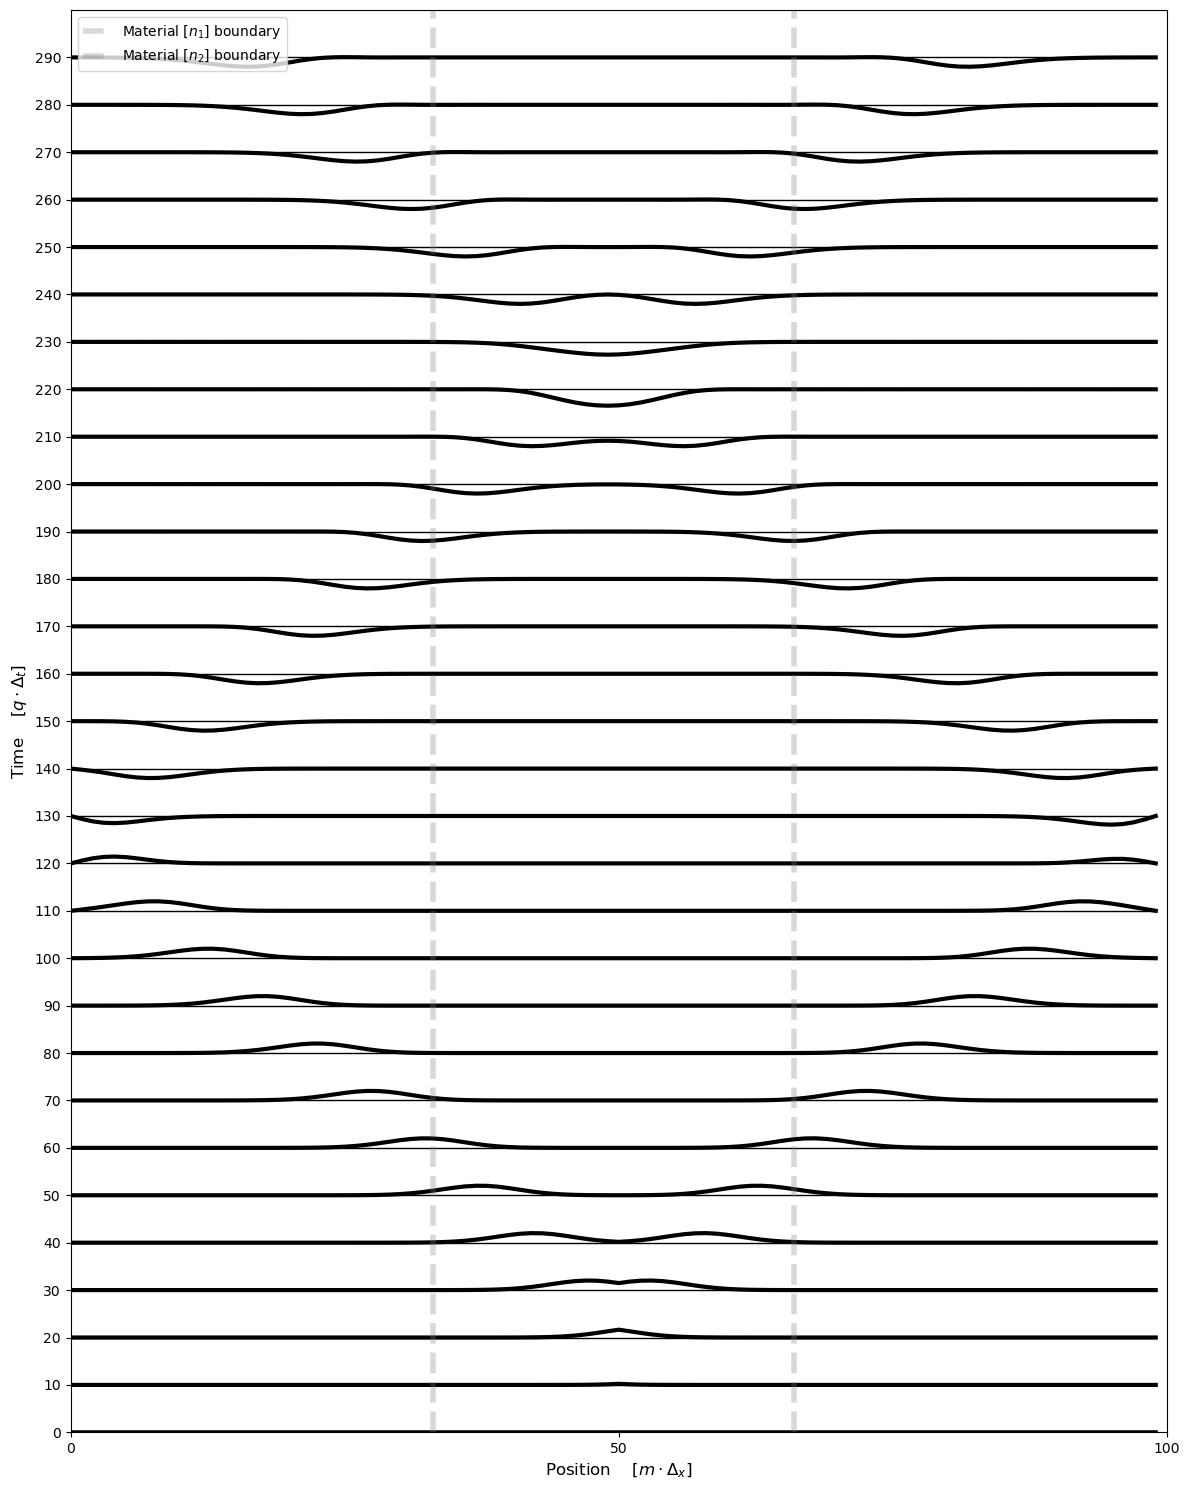

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import epsilon_0, mu_0, c

## -- Establishing constants and grids -- ## 
NT = 300 # time grid length
NX = 100 # space grid length
src_x = 50 # x position of source
n2 = 1 # new medium at x = 33 rescaling
n3 = 1 # new medium at x = 66

Hy = np.zeros(NX) 
Ez = np.zeros(NX)
Ez_T = np.zeros((NT, NX))
src_d = 25
src_w = 10 

e0 = np.ones(NX) * epsilon_0 # permittivity
e0[int(NX/3):] = epsilon_0 * n2 # e0 after passing through boundary
e0[int(2*NX/3):] = epsilon_0 * n3 # e0 after passing through boundary

u0 = mu_0 # permeability
eta_0 = np.sqrt(u0 / e0) # impedance
dx = 1e-3 
dt = dx / (2 * c) 

c_H = dt / (u0 * dx)  # update coeff for B-field
c_E = dt / (e0 * dx)  # update coeff for E-field

## -- Running FDTD -- ##
## Note: did not write it to absorb energy at boundaries, so amplitudes are perfectly reflected at the edges

for q in range(NT):
    Hy[:-1] += c_H * (Ez[1:] - Ez[:-1]) # update next Hy value
    Ez[1:-1] += c_E[1:-1] * (Hy[1:-1] - Hy[:-2]) # update next Ez value
    Ez[src_x] += np.exp(-((q - src_d) / src_w) ** 2) # 
    Ez_T[q, :] = Ez

plt.figure(figsize=(12, 15))
time_steps = np.arange(0, NT, 10)
amplitude_scale = 2.0 # rescales pulse height

for q in time_steps:
    ez_profile = Ez_T[q, :] # extract pulse slice at qth timestep 
    plt.plot([0, NX-1], [q, q], color='black', linewidth=1, zorder=1)
    plt.plot(ez_profile * amplitude_scale + q, color='black', linewidth=3, zorder=2)

plt.axvline(x=33,ls="--",color="gray",alpha=0.3,lw=4,label=r"Material [$n_1$] boundary")
plt.axvline(x=66,ls="--",color="gray",alpha=0.3,lw=4,label=r"Material [$n_2$] boundary")

plt.xlim(0, NX)
plt.ylim(0, NT)
plt.xticks([0, 50, 100])
plt.yticks(time_steps)

plt.xlabel(r'Position    $[m \cdot \Delta_x]$', fontsize=12)
plt.ylabel(r'Time    $[q \cdot \Delta_t]$', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()